In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer

In [13]:
df = pd.read_csv("spam_ham_dataset.csv")
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [14]:
df.columns

Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')

In [15]:
df = df.drop("Unnamed: 0", axis=1)

In [16]:
X = df["text"]        # Message text
y = df["label_num"]  # 0 = ham, 1 = spam

In [17]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [19]:
model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

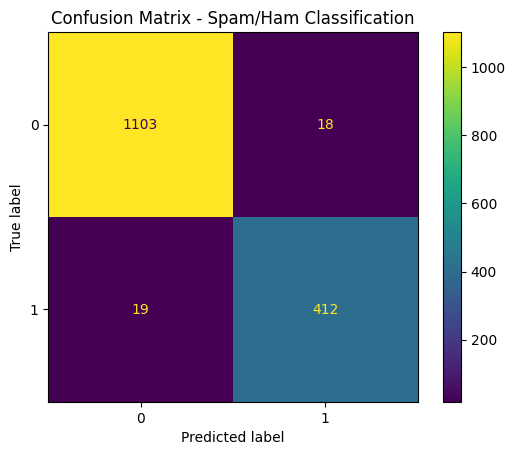

In [20]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Spam/Ham Classification")
plt.show()

In [21]:
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

TP: 412
FP: 18
TN: 1103
FN: 19
Accuracy: 0.976159793814433
Error Rate: 0.023840206185567037
Precision: 0.958139534883721
Recall: 0.9559164733178654
